<a href="https://colab.research.google.com/github/FiloEmad/Solship_ML_Hackathon/blob/main/Solship_ML_Hackathon_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import pandas as pd

# Attempt to read the CSV, letting pandas infer the separator
ENERGY_Hackathon_df = pd.read_csv('/content/ENERGY_Hackathon_DataSet(Sheet1).csv', sep=None, engine='python')

display(ENERGY_Hackathon_df.head())

,battery_p,grid_p,load_p,pv_p,timestamp,Selling_price_eur_kwh
0,0,"3,04","3,05",0,2024-01-01 00:00:00,"0,10709"
1,0,"0,34","0,34",0,2024-01-01 00:15:00,"0,10709"
2,0,"0,37","0,37",0,2024-01-01 00:30:00,"0,10709"
3,0,"0,37","0,37",0,2024-01-01 00:45:00,"0,10709"
4,0,"2,4","2,4",0,2024-01-01 01:00:00,"0,104"


In [13]:
ENERGY_Hackathon_df_filtered = ENERGY_Hackathon_df[['timestamp', 'load_p']]
display(ENERGY_Hackathon_df_filtered.head())

,timestamp,load_p
0,2024-01-01 00:00:00,"3,05"
1,2024-01-01 00:15:00,"0,34"
2,2024-01-01 00:30:00,"0,37"
3,2024-01-01 00:45:00,"0,37"
4,2024-01-01 01:00:00,"2,4"


In [14]:
print('Missing values in weather_df_15min:')
display(ENERGY_Hackathon_df_filtered.isnull().sum())

Missing values in weather_df_15min:


,0
timestamp,0
load_p,0


In [15]:
# Convert 'timestamp' to datetime objects
ENERGY_Hackathon_df_filtered['timestamp'] = pd.to_datetime(ENERGY_Hackathon_df_filtered['timestamp'])

# Convert 'load_p' to numeric, replacing comma with dot for decimal
ENERGY_Hackathon_df_filtered['load_p'] = ENERGY_Hackathon_df_filtered['load_p'].str.replace(',', '.', regex=False).astype(float)

display(ENERGY_Hackathon_df_filtered.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70077 entries, 0 to 70076
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  70077 non-null  datetime64[ns]
 1   load_p     70077 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 1.1 MB


/tmp/ipykernel_3775/1435214854.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ENERGY_Hackathon_df_filtered['timestamp'] = pd.to_datetime(ENERGY_Hackathon_df_filtered['timestamp'])
/tmp/ipykernel_3775/1435214854.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ENERGY_Hackathon_df_filtered['load_p'] = ENERGY_Hackathon_df_filtered['load_p'].str.replace(',', '.', regex=False).astype(float)


None

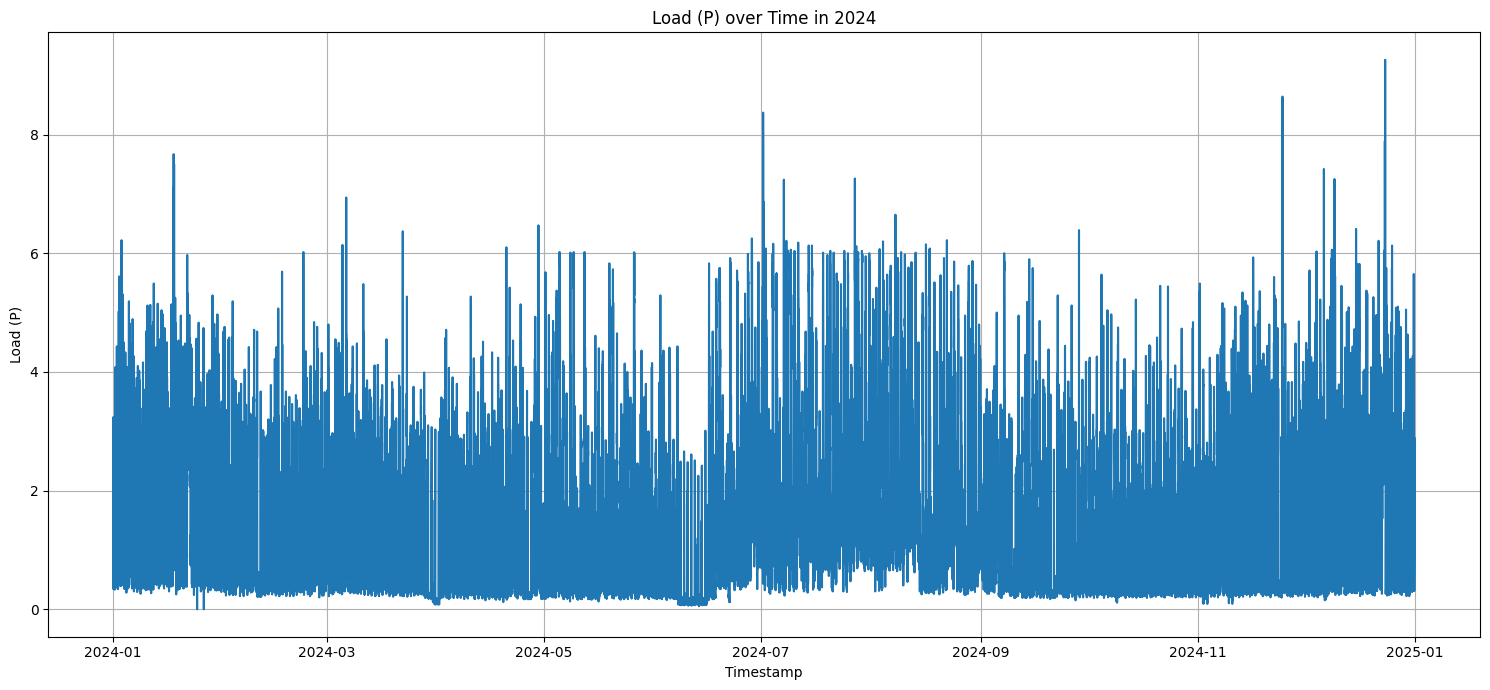

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter data for the year 2024 only
ENERGY_Hackathon_df_2024 = ENERGY_Hackathon_df_filtered[ENERGY_Hackathon_df_filtered['timestamp'].dt.year == 2024]

plt.figure(figsize=(15, 7))
sns.lineplot(x='timestamp', y='load_p', data=ENERGY_Hackathon_df_2024)
plt.title('Load (P) over Time in 2024')
plt.xlabel('Timestamp')
plt.ylabel('Load (P)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [17]:
import pandas as pd
import numpy as np

# =========================
# LOAD DATA
# =========================

# Example:
df = ENERGY_Hackathon_df_2024

# Ensure timestamp is datetime
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Sort by time
df = df.sort_values("timestamp").reset_index(drop=True)

# =========================
# BASIC TIME FEATURES
# =========================

df["hour"] = df["timestamp"].dt.hour
df["minute"] = df["timestamp"].dt.minute
df["dayofweek"] = df["timestamp"].dt.dayofweek
df["day"] = df["timestamp"].dt.day
df["month"] = df["timestamp"].dt.month
df["weekofyear"] = df["timestamp"].dt.isocalendar().week.astype(int)

# Weekend flag
df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)

# =========================
# CYCLICAL ENCODING
# =========================

# Hour cyclic encoding
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

# Day of week cyclic encoding
df["dow_sin"] = np.sin(2 * np.pi * df["dayofweek"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["dayofweek"] / 7)

# Month cyclic encoding
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

# =========================
# LAG FEATURES
# =========================

target = "load_p"

# # 15 min ago
# df["lag_1"] = df[target].shift(1)

# # 1 hour ago
# df["lag_4"] = df[target].shift(4)

# 6 hours ago
df["lag_24"] = df[target].shift(24)

# Same time yesterday
df["lag_96"] = df[target].shift(96)

# Same time last week
df["lag_672"] = df[target].shift(672)

# # =========================
# # ROLLING / WINDOW FEATURES
# # =========================

# # Last 1 hour mean
# df["rolling_mean_4"] = (
#     df[target]
#     .shift(1)
#     .rolling(window=4)
#     .mean()
# )

# # Last 6 hour mean
# df["rolling_mean_24"] = (
#     df[target]
#     .shift(1)
#     .rolling(window=24)
#     .mean()
# )

# # Last 24 hour mean
# df["rolling_mean_96"] = (
#     df[target]
#     .shift(1)
#     .rolling(window=96)
#     .mean()
# )

# # Rolling standard deviation
# df["rolling_std_96"] = (
#     df[target]
#     .shift(1)
#     .rolling(window=96)
#     .std()
# )

# # Rolling max
# df["rolling_max_96"] = (
#     df[target]
#     .shift(1)
#     .rolling(window=96)
#     .max()
# )

# # Rolling min
# df["rolling_min_96"] = (
#     df[target]
#     .shift(1)
#     .rolling(window=96)
#     .min()
# )

# # =========================
# # EXPONENTIAL MOVING AVERAGE
# # =========================

# df["ema_24"] = (
#     df[target]
#     .shift(1)
#     .ewm(span=24, adjust=False)
#     .mean()
# )

# df["ema_96"] = (
#     df[target]
#     .shift(1)
#     .ewm(span=96, adjust=False)
#     .mean()
# )

# # =========================
# # DIFFERENCE FEATURES
# # =========================

# # Difference from previous timestep
# df["diff_1"] = df[target].diff(1)

# # Difference from yesterday
# df["diff_96"] = df[target].diff(96)

# =========================
# HANDLE MISSING VALUES
# =========================

# Remove rows created by lag/rolling
df = df.dropna().reset_index(drop=True)

# =========================
# FEATURE LIST
# =========================

feature_cols = [col for col in df.columns
                if col not in ["timestamp", target]]

X_train = df[feature_cols]
y_train = df[target]

print("Feature count:", len(feature_cols))
print(feature_cols)

Feature count: 16
['hour', 'minute', 'dayofweek', 'day', 'month', 'weekofyear', 'is_weekend', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'lag_24', 'lag_96', 'lag_672']


/tmp/ipykernel_3775/712295044.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["timestamp"] = pd.to_datetime(df["timestamp"])


In [18]:
import pandas as pd
import numpy as np

# =========================
# LOAD DATA
# =========================

ENERGY_Hackathon_df_2025 = ENERGY_Hackathon_df_filtered[ENERGY_Hackathon_df_filtered['timestamp'].dt.year == 2025]
df = ENERGY_Hackathon_df_2025

# Ensure timestamp is datetime
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Sort by time
df = df.sort_values("timestamp").reset_index(drop=True)

# =========================
# BASIC TIME FEATURES
# =========================

df["hour"] = df["timestamp"].dt.hour
df["minute"] = df["timestamp"].dt.minute
df["dayofweek"] = df["timestamp"].dt.dayofweek
df["day"] = df["timestamp"].dt.day
df["month"] = df["timestamp"].dt.month
df["weekofyear"] = df["timestamp"].dt.isocalendar().week.astype(int)

# Weekend flag
df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)

# =========================
# CYCLICAL ENCODING
# =========================

# Hour cyclic encoding
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

# Day of week cyclic encoding
df["dow_sin"] = np.sin(2 * np.pi * df["dayofweek"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["dayofweek"] / 7)

# Month cyclic encoding
df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

# =========================
# LAG FEATURES
# =========================

target = "load_p"

# # 15 min ago
# df["lag_1"] = df[target].shift(1)

# # 1 hour ago
# df["lag_4"] = df[target].shift(4)

# 6 hours ago
df["lag_24"] = df[target].shift(24)

# Same time yesterday
df["lag_96"] = df[target].shift(96)

# Same time last week
df["lag_672"] = df[target].shift(672)

# # =========================
# # ROLLING / WINDOW FEATURES
# # =========================

# # Last 1 hour mean
# df["rolling_mean_4"] = (
#     df[target]
#     .shift(1)
#     .rolling(window=4)
#     .mean()
# )

# # Last 6 hour mean
# df["rolling_mean_24"] = (
#     df[target]
#     .shift(1)
#     .rolling(window=24)
#     .mean()
# )

# # Last 24 hour mean
# df["rolling_mean_96"] = (
#     df[target]
#     .shift(1)
#     .rolling(window=96)
#     .mean()
# )

# # Rolling standard deviation
# df["rolling_std_96"] = (
#     df[target]
#     .shift(1)
#     .rolling(window=96)
#     .std()
# )

# # Rolling max
# df["rolling_max_96"] = (
#     df[target]
#     .shift(1)
#     .rolling(window=96)
#     .max()
# )

# # Rolling min
# df["rolling_min_96"] = (
#     df[target]
#     .shift(1)
#     .rolling(window=96)
#     .min()
# )

# # =========================
# # EXPONENTIAL MOVING AVERAGE
# # =========================

# df["ema_24"] = (
#     df[target]
#     .shift(1)
#     .ewm(span=24, adjust=False)
#     .mean()
# )

# df["ema_96"] = (
#     df[target]
#     .shift(1)
#     .ewm(span=96, adjust=False)
#     .mean()
# )

# # =========================
# # DIFFERENCE FEATURES
# # =========================

# # Difference from previous timestep
# df["diff_1"] = df[target].diff(1)

# # Difference from yesterday
# df["diff_96"] = df[target].diff(96)

# =========================
# HANDLE MISSING VALUES
# =========================

# Remove rows created by lag/rolling
df = df.dropna().reset_index(drop=True)

# =========================
# FEATURE LIST
# =========================

feature_cols = [col for col in df.columns
                if col not in ["timestamp", target]]

X_test = df[feature_cols]
y_test = df[target]

print("Feature count:", len(feature_cols))
print(feature_cols)

Feature count: 16
['hour', 'minute', 'dayofweek', 'day', 'month', 'weekofyear', 'is_weekend', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'lag_24', 'lag_96', 'lag_672']


/tmp/ipykernel_3775/487863827.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["timestamp"] = pd.to_datetime(df["timestamp"])


In [19]:
# =========================================================
# AUTOREGRESSIVE LOAD FORECASTING MODEL
# Optimized for Energy Forecasting Hackathon
# =========================================================

# =========================================================
# INSTALL (COLAB)
# =========================================================

# !pip install lightgbm -q

# =========================================================
# IMPORTS
# =========================================================

import pandas as pd
import numpy as np

from lightgbm import LGBMRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

# =========================================================
# MODEL
# =========================================================

model = LGBMRegressor(

    # -----------------------------------------
    # Core
    # -----------------------------------------

    objective="regression",

    # -----------------------------------------
    # Trees
    # -----------------------------------------

    n_estimators=2000,
    learning_rate=0.01,

    num_leaves=64,
    max_depth=10,

    # -----------------------------------------
    # Regularization
    # -----------------------------------------

    subsample=0.8,
    colsample_bytree=0.8,

    reg_alpha=0.5,
    reg_lambda=0.5,

    # -----------------------------------------
    # Stability
    # -----------------------------------------

    random_state=42,

    # -----------------------------------------
    # Speed
    # -----------------------------------------

    n_jobs=-1
)

# =========================================================
# TRAIN
# =========================================================

model.fit(
    X_train,
    y_train
)

# =========================================================
# AUTOREGRESSIVE FORECASTING
# =========================================================

test_forecast = []

# We use recursive autoregression:
# each prediction becomes future lag input

# Fix: Initialize test_recursive with the DataFrame that already has all engineered features (df from previous cell).
test_recursive = df.copy()

for i in range(len(test_recursive)):

    row = test_recursive.iloc[i]

    X_row = row[feature_cols].values.reshape(1, -1)

    pred = model.predict(X_row)[0]

    test_forecast.append(pred)

    # -----------------------------------------
    # Update future rows recursively
    # -----------------------------------------

    if i + 1 < len(test_recursive):

        test_recursive.loc[
            i + 1,
            "lag_1"
        ] = pred

# =========================================================
# EVALUATION
# =========================================================

preds = np.array(test_forecast)

rmse = np.sqrt(
    mean_squared_error(y_test, preds)
)

mae = mean_absolute_error(
    y_test,
    preds
)

nrmse = (
    rmse / y_test.mean()
) * 100

# =========================================================
# RESULTS
# =========================================================

print("=" * 50)
print("FORECAST RESULTS")
print("=" * 50)

print(f"RMSE  : {rmse:.4f} kW")
print(f"MAE   : {mae:.4f} kW")
print(f"NRMSE : {nrmse:.2f} %")

# =========================================================
# SAVE PREDICTIONS
# =========================================================

results_df = pd.DataFrame({

    "timestamp": test_recursive["timestamp"], # Fixed: Use timestamp from test_recursive
    "actual_load": y_test.values,
    "forecast_load": preds
})

results_df.to_csv(
    "forecast_results.csv",
    index=False
)

print("\nForecast saved.")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001663 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 976
[LightGBM] [Info] Number of data points in the train set: 34464, number of used features: 16
[LightGBM] [Info] Start training from score 1.475209
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr

FORECAST RESULTS
RMSE  : 1.1402 kW
MAE   : 0.8372 kW
NRMSE : 78.06 %

Forecast saved.


In [20]:
# =========================================================
# AUTOREGRESSIVE LOAD FORECASTING MODEL
# Optimized for Energy Forecasting Hackathon
# =========================================================

# =========================================================
# INSTALL (COLAB)
# =========================================================

# !pip install lightgbm -q

# =========================================================
# IMPORTS
# =========================================================

import pandas as pd
import numpy as np

from lightgbm import LGBMRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

# =========================================================
# MODEL
# =========================================================

model = LGBMRegressor(

    # -----------------------------------------
    # Core
    # -----------------------------------------

    objective="regression",

    # -----------------------------------------
    # Trees
    # -----------------------------------------

    n_estimators=2000,
    learning_rate=0.01,

    num_leaves=64,
    max_depth=10,

    # -----------------------------------------
    # Regularization
    # -----------------------------------------

    subsample=0.8,
    colsample_bytree=0.8,

    reg_alpha=0.5,
    reg_lambda=0.5,

    # -----------------------------------------
    # Stability
    # -----------------------------------------

    random_state=42,

    # -----------------------------------------
    # Speed
    # -----------------------------------------

    n_jobs=-1
)

# =========================================================
# TRAIN
# =========================================================

model.fit(
    X_train,
    y_train
)

# =========================================================
# AUTOREGRESSIVE FORECASTING
# =========================================================

test_forecast = []

# We use recursive autoregression:
# each prediction becomes future lag input

# Fix: Initialize test_recursive with the DataFrame that already has all engineered features (df from previous cell).
test_recursive = df.copy()

for i in range(len(test_recursive)):

    row = test_recursive.iloc[i]

    X_row = row[feature_cols].values.reshape(1, -1)

    pred = model.predict(X_row)[0]

    test_forecast.append(pred)

    # -----------------------------------------
    # Update future rows recursively

# =========================================================
# EVALUATION
# =========================================================

preds = np.array(test_forecast)

rmse = np.sqrt(
    mean_squared_error(y_test, preds)
)

mae = mean_absolute_error(
    y_test,
    preds
)

nrmse = (
    rmse / y_test.mean()
) * 100

# =========================================================
# RESULTS
# =========================================================

print("=" * 50)
print("FORECAST RESULTS")
print("=" * 50)

print(f"RMSE  : {rmse:.4f} kW")
print(f"MAE   : {mae:.4f} kW")
print(f"NRMSE : {nrmse:.2f} %")

# =========================================================
# SAVE PREDICTIONS
# =========================================================

results_df = pd.DataFrame({

    "timestamp": test_recursive["timestamp"], # Fixed: Use timestamp from test_recursive
    "actual_load": y_test.values,
    "forecast_load": preds
})

results_df.to_csv(
    "forecast_results.csv",
    index=False
)

print("\nForecast saved.")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001652 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 976
[LightGBM] [Info] Number of data points in the train set: 34464, number of used features: 16
[LightGBM] [Info] Start training from score 1.475209
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr

FORECAST RESULTS
RMSE  : 1.1402 kW
MAE   : 0.8372 kW
NRMSE : 78.06 %

Forecast saved.


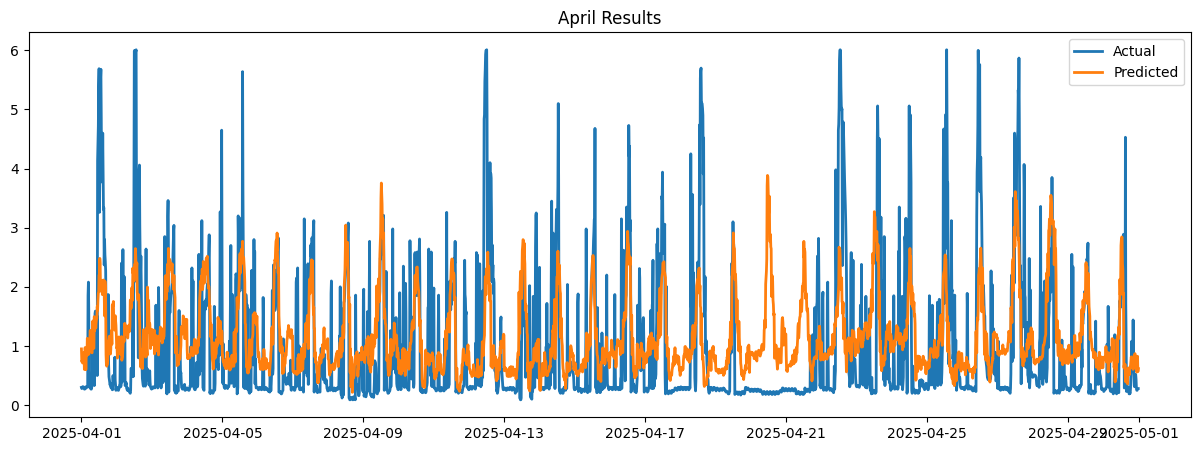

===== April Results =====
RMSE : 0.996530386855355
MAE  : 0.7415335496511454
NRMSE: 0.16833283561745863




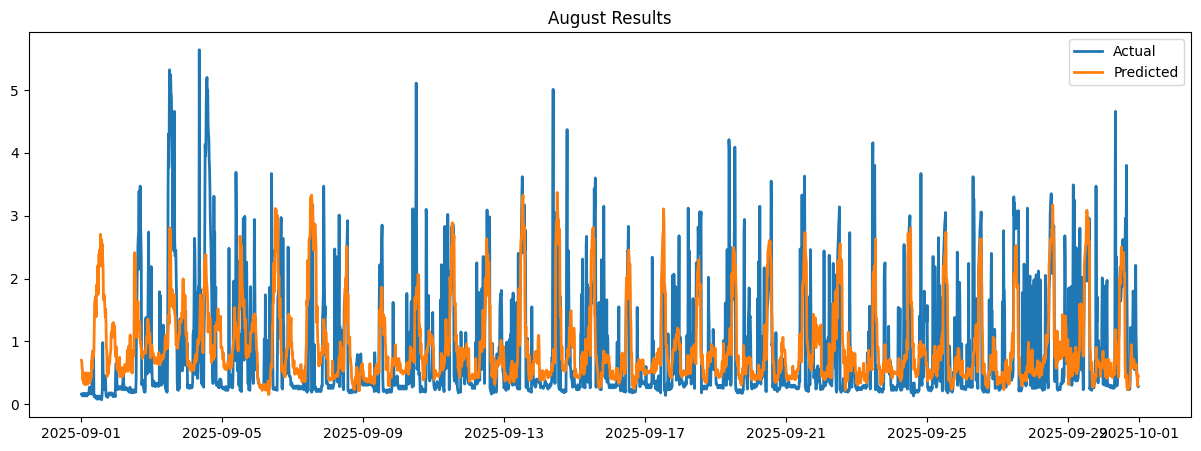

===== August Results =====
RMSE : 0.8148707451392827
MAE  : 0.5528397462004596
NRMSE: 0.14629636357976353




In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

target = "load_p"

# =========================
# METRICS FUNCTION
# =========================
def compute_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    nrmse = rmse / (y_true.max() - y_true.min())
    return rmse, mae, nrmse


# =========================
# PLOT FUNCTION
# =========================
def plot_results(df_month, title):

    plt.figure(figsize=(15,5))
    plt.plot(df_month["timestamp"], df_month["actual_load"], label="Actual", linewidth=2)
    plt.plot(df_month["timestamp"], df_month["forecast_load"], label="Predicted", linewidth=2)
    plt.title(title)
    plt.legend()
    plt.show()


    rmse, mae, nrmse = compute_metrics(
        df_month["actual_load"],
        df_month["forecast_load"]
    )

    print(f"===== {title} =====")
    print("RMSE :", rmse)
    print("MAE  :", mae)
    print("NRMSE:", nrmse)
    print("\n")


# =========================
# LOAD YOUR FILE
# =========================
df = pd.read_csv("/content/forecast_results.csv")  # <-- file بتاعك

df["timestamp"] = pd.to_datetime(df["timestamp"])

# =========================
# STANDARDIZE COLUMN NAMES
# =========================
df = df.rename(columns={
    "actual": "actual_load",
    "predicted": "forecast_load"
})

# =========================
# APRIL
# =========================
april_df = df[
    df["timestamp"].dt.month == 4
].copy()

plot_results(april_df, "April Results")

# =========================
# AUGUST
# =========================
aug_df = df[
    df["timestamp"].dt.month == 9
].copy()

plot_results(aug_df, "August Results")